<a href="https://colab.research.google.com/github/lunecarvalho/ml-ai-studies/blob/main/03_sales_forecast_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

dados_vendas = {
    'mes': [
        'Janeiro', 'Fevereiro', 'Março', 'Abril', 'Maio', 'Junho',
        'Julho', 'Agosto', 'Setembro', 'Outubro', 'Novembro', 'Dezembro'
    ],
    'vendas': [
        2000, 2200, 2300, 2500, 2600, 2700,
        2800, 2900, 3000, 3100, 3200, 3300
    ]
}

df_vendas = pd.DataFrame(dados_vendas)

# Criar uma representação numérica dos meses
df_vendas['mes_numero'] = range(1, 13)

In [3]:
# Verificar dados nulos
print(df_vendas.isnull().sum())

# Verificar dados duplicados
print(f'Duplicados: {df_vendas.duplicated().sum()}')

mes           0
vendas        0
mes_numero    0
dtype: int64
Duplicados: 0


In [4]:
df_vendas

,mes,vendas,mes_numero
0,Janeiro,2000,1
1,Fevereiro,2200,2
2,Março,2300,3
3,Abril,2500,4
4,Maio,2600,5
5,Junho,2700,6
6,Julho,2800,7
7,Agosto,2900,8
8,Setembro,3000,9
9,Outubro,3100,10


In [5]:
df_vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   mes         12 non-null     object
 1   vendas      12 non-null     int64 
 2   mes_numero  12 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 420.0+ bytes


In [6]:
df_vendas['vendas_formatadas'] = df_vendas['vendas'].apply(
    lambda x: f'R$ {x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')
)

df_vendas

,mes,vendas,mes_numero,vendas_formatadas
0,Janeiro,2000,1,"R$ 2.000,00"
1,Fevereiro,2200,2,"R$ 2.200,00"
2,Março,2300,3,"R$ 2.300,00"
3,Abril,2500,4,"R$ 2.500,00"
4,Maio,2600,5,"R$ 2.600,00"
5,Junho,2700,6,"R$ 2.700,00"
6,Julho,2800,7,"R$ 2.800,00"
7,Agosto,2900,8,"R$ 2.900,00"
8,Setembro,3000,9,"R$ 3.000,00"
9,Outubro,3100,10,"R$ 3.100,00"


In [7]:
# Dados para treinamento
X = df_vendas[['mes_numero']].iloc[:-1]
y = df_vendas['vendas'].iloc[:-1]

modelo = LinearRegression()

modelo.fit(X, y)

LinearRegression()

In [8]:
print(f'Coeficiente: {modelo.coef_[0]:.2f}')
print(f'Intercepto: {modelo.intercept_:.2f}')

Coeficiente: 115.45
Intercepto: 1970.91


In [11]:
mes_dezembro = [[12]]

previsao_dezembro = modelo.predict(mes_dezembro)

print(
    f'Previsão de vendas para dezembro: '
    f'R$ {previsao_dezembro[0]:,.2f}'
    .replace(',', 'X')
    .replace('.', ',')
    .replace('X', '.')
)

Previsão de vendas para dezembro: R$ 3.356,36


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


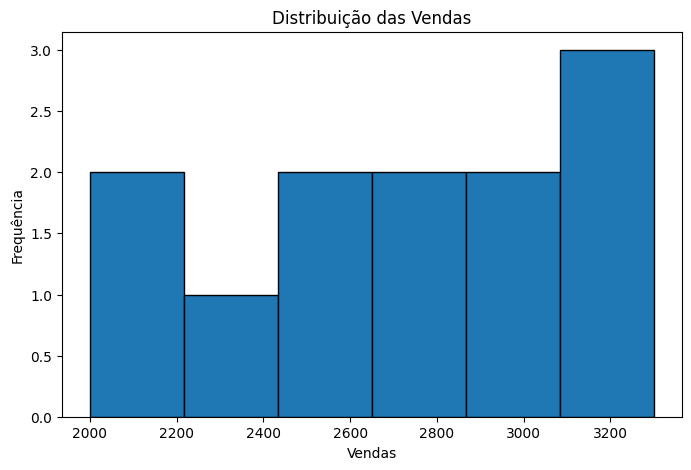

In [12]:
plt.figure(figsize=(8, 5))

plt.hist(df_vendas['vendas'], bins=6, edgecolor='black')

plt.title('Distribuição das Vendas')
plt.xlabel('Vendas')
plt.ylabel('Frequência')

plt.show()

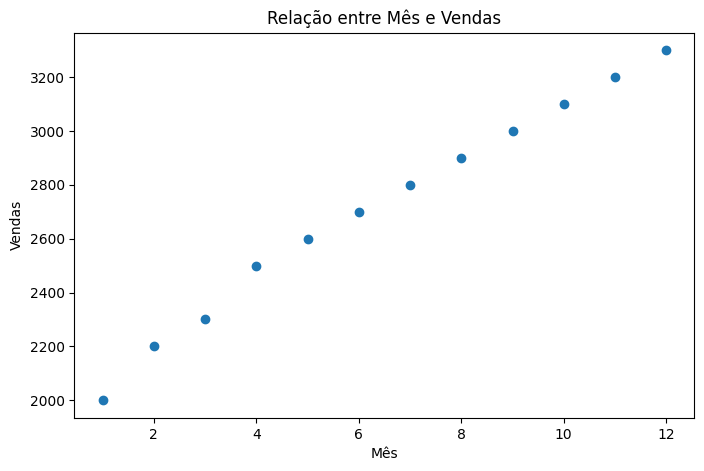

In [13]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_vendas['mes_numero'],
    df_vendas['vendas']
)

plt.title('Relação entre Mês e Vendas')
plt.xlabel('Mês')
plt.ylabel('Vendas')

plt.show()

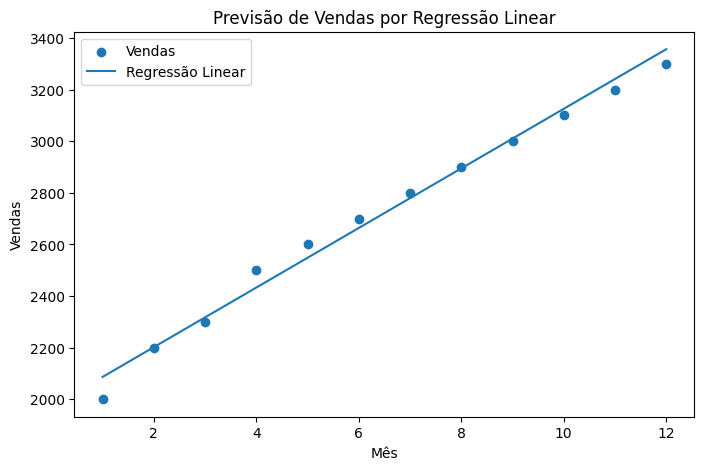

In [14]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_vendas['mes_numero'],
    df_vendas['vendas'],
    label='Vendas'
)

plt.plot(
    df_vendas['mes_numero'],
    modelo.predict(df_vendas[['mes_numero']]),
    label='Regressão Linear'
)

plt.title('Previsão de Vendas por Regressão Linear')
plt.xlabel('Mês')
plt.ylabel('Vendas')
plt.legend()

plt.show()